## Application of the maximum flow algorithm for goods logistics


### Imports


In [34]:
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import networkx as nx

### Creating and drawing the graph


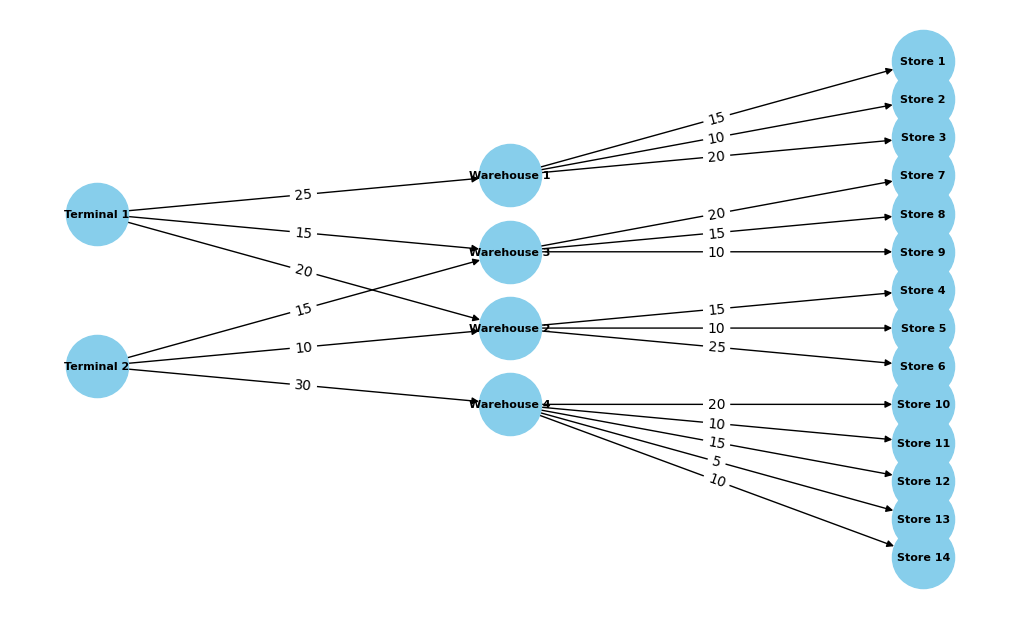

In [35]:
# Creating a graph
G = nx.DiGraph()

# Adding edges with bandwidth
edges = [
    ("Terminal 1", "Warehouse 1", 25),
    ("Terminal 1", "Warehouse 2", 20),
    ("Terminal 1", "Warehouse 3", 15),
    ("Terminal 2", "Warehouse 3", 15),
    ("Terminal 2", "Warehouse 4", 30),
    ("Terminal 2", "Warehouse 2", 10),
    ("Warehouse 1", "Store 1", 15),
    ("Warehouse 1", "Store 2", 10),
    ("Warehouse 1", "Store 3", 20),
    ("Warehouse 2", "Store 4", 15),
    ("Warehouse 2", "Store 5", 10),
    ("Warehouse 2", "Store 6", 25),
    ("Warehouse 3", "Store 7", 20),
    ("Warehouse 3", "Store 8", 15),
    ("Warehouse 3", "Store 9", 10),
    ("Warehouse 4", "Store 10", 20),
    ("Warehouse 4", "Store 11", 10),
    ("Warehouse 4", "Store 12", 15),
    ("Warehouse 4", "Store 13", 5),
    ("Warehouse 4", "Store 14", 10),
]

nodes = [
    "Terminal 1",
    "Terminal 2",
    "Warehouse 1",
    "Warehouse 2",
    "Warehouse 3",
    "Warehouse 4",
    "Store 1",
    "Store 2",
    "Store 3",
    "Store 4",
    "Store 5",
    "Store 6",
    "Store 7",
    "Store 8",
    "Store 9",
    "Store 10",
    "Store 11",
    "Store 12",
    "Store 13",
    "Store 14",
    "SuperSource",  # required because the Edmonds-Karp algorithm foresees only 1 source, not 2
    "SuperSink",  # required because the Edmonds-Karp algorithm foresees only 1 sinc, not 14
]

# Add all edges to the graph
G.add_weighted_edges_from(edges)

# Positions for drawing a graph
pos = {
    "Terminal 1": (0, 2.5),
    "Terminal 2": (0, 0.5),
    "Warehouse 1": (2, 3),
    "Warehouse 2": (2, 1),
    "Warehouse 3": (2, 2),
    "Warehouse 4": (2, 0),
    "Store 1": (4, 4.5),
    "Store 2": (4, 4.0),
    "Store 3": (4, 3.5),
    "Store 4": (4, 1.5),
    "Store 5": (4, 1.0),
    "Store 6": (4, 0.5),
    "Store 7": (4, 3.0),
    "Store 8": (4, 2.5),
    "Store 9": (4, 2.0),
    "Store 10": (4, 0.0),
    "Store 11": (4, -0.5),
    "Store 12": (4, -1.0),
    "Store 13": (4, -1.5),
    "Store 14": (4, -2.0),
}

# Drawing a graph
plt.figure(figsize=(10, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="skyblue",
    font_size=8,
    font_weight="bold",
    arrows=True,
)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# Displaying the graph
plt.show()

### Finding the maximum flow from source to sink


Functions for implementing the Edmonds-Karp algorithm


In [36]:
def bfs(
    capacity_matrix: list[list[int]],
    flow_matrix: list[list[int]],
    source: int,
    sink: int,
    parent: list[int],
) -> bool:
    """
    Function for maximizing path search (BFS)
    """
    visited = [False] * len(capacity_matrix)
    queue = deque([source])
    visited[source] = True
    while queue:
        current_node = queue.popleft()
        for neighbor in range(len(capacity_matrix)):
            # Check if there is residual bandwidth in the channel
            if (
                not visited[neighbor]
                and capacity_matrix[current_node][neighbor]
                - flow_matrix[current_node][neighbor]
                > 0
            ):
                parent[neighbor] = current_node
                visited[neighbor] = True
                if neighbor == sink:
                    return True
                queue.append(neighbor)
    return False


def edmonds_karp(
    capacity_matrix: list[list[int]], source: int, sink: int
) -> tuple[float, list[list[int]]]:
    """
    Basic function for calculating maximum flow
    """
    num_nodes = len(capacity_matrix)
    flow_matrix = [[0] * num_nodes for _ in range(num_nodes)]
    parent = [-1] * num_nodes
    max_flow = 0

    while bfs(capacity_matrix, flow_matrix, source, sink, parent):
        # Find the minimum throughput along the found path (bottleneck)
        path_flow = float("inf")
        current_node = sink
        while current_node != source:
            previous_node = parent[current_node]
            path_flow = min(
                path_flow,
                capacity_matrix[previous_node][current_node]
                - flow_matrix[previous_node][current_node],
            )
            current_node = previous_node

        # Update the flow along the path, taking into account the return flow
        current_node = sink
        while current_node != source:
            previous_node = parent[current_node]
            flow_matrix[previous_node][current_node] += path_flow
            flow_matrix[current_node][previous_node] -= path_flow
            current_node = previous_node

        # Increase the maximum flow
        max_flow += path_flow

    return max_flow, flow_matrix

Mapping the nodes


In [37]:
node_to_index = {name: idx for idx, name in enumerate(nodes)}
index_to_node = {idx: name for name, idx in node_to_index.items()}
n = len(nodes)

Capacity matrix


In [38]:
capacity_matrix = [[0] * n for _ in range(n)]

for u, v, c in edges:
    capacity_matrix[node_to_index[u]][node_to_index[v]] = c

# Add SuperSource and SuperSink
capacity_matrix[node_to_index["SuperSource"]][node_to_index["Terminal 1"]] = float(
    "inf"
)
capacity_matrix[node_to_index["SuperSource"]][node_to_index["Terminal 2"]] = float(
    "inf"
)
for node in nodes:
    if node.startswith("Store"):
        capacity_matrix[node_to_index[node]][node_to_index["SuperSink"]] = float("inf")

Resolution


In [ ]:
source = node_to_index["SuperSource"]
sink = node_to_index["SuperSink"]
max_flow, flow_matrix = edmonds_karp(capacity_matrix, source, sink)

# Extract Terminal -> Store Flows
terminal_store_flow = defaultdict(int)
for warehouse in ["Warehouse 1", "Warehouse 2", "Warehouse 3", "Warehouse 4"]:
    warehouse_idx = node_to_index[warehouse]
    inflow_by_terminal = {
        term: flow_matrix[node_to_index[term]][warehouse_idx]
        for term in ["Terminal 1", "Terminal 2"]
        if flow_matrix[node_to_index[term]][warehouse_idx] > 0
    }
    total_in = sum(inflow_by_terminal.values())
    for store in [n for n in nodes if n.startswith("Store")]:
        store_idx = node_to_index[store]
        outflow = flow_matrix[warehouse_idx][store_idx]
        if outflow >= 0 and total_in >= 0:
            for term, inflow in inflow_by_terminal.items():
                share = round((inflow / total_in) * outflow, 2)
                terminal_store_flow[(term, store)] += share

print("\nActual Flows from Terminals to Stores:")
print("----------------------------------------")
print(f"{'Terminal':<12} {'Store':<10} {'Flow (units)':<14}")
print("----------------------------------------")
for (terminal, store), flow in sorted(terminal_store_flow.items()):
    print(f"{terminal:<12} {store:<10} {flow:<14}")

print(f"\nTotal Maximum Flow from SuperSource to SuperSink: {max_flow} units")


Actual Flows from Terminals to Stores:
----------------------------------------
Terminal     Store      Flow (units)  
----------------------------------------
Terminal 1   Store 1    15.0          
Terminal 1   Store 10   0.0           
Terminal 1   Store 11   0.0           
Terminal 1   Store 12   0.0           
Terminal 1   Store 13   0.0           
Terminal 1   Store 14   0.0           
Terminal 1   Store 2    10.0          
Terminal 1   Store 3    0.0           
Terminal 1   Store 4    10.0          
Terminal 1   Store 5    6.67          
Terminal 1   Store 6    3.33          
Terminal 1   Store 7    10.0          
Terminal 1   Store 8    5.0           
Terminal 1   Store 9    0.0           
Terminal 2   Store 1    0.0           
Terminal 2   Store 10   20.0          
Terminal 2   Store 11   10.0          
Terminal 2   Store 12   0.0           
Terminal 2   Store 13   0.0           
Terminal 2   Store 14   0.0           
Terminal 2   Store 2    0.0           
Terminal 2   Store 3

### Conclusions:
1. Terminal 1 provides a slightly larger flow of goods to stores than Terminal 2, 60 versus 55 units of goods.
2. Routes between terminals and warehouses have a lower capacity than routes between warehouses and stores, 115 versus 200 units of goods.
3. Stores 3, 9, 12, 13, 14 are not receiving any goods at all. To increase their supply, it is necessary to increase the capacity of the routes from the terminals to the warehouses.
4. It is necessary to remove bottlenecks between terminals and warehouses to improve the efficiency of the logistics network.